<br>
<p style="font-family:Georgia; font-size:2.75em;color:Black; font-style:bold; font-weight:700"><br>
Case Study on Olympic Sports Medal Data </p><br>
<br>
<br>
<br>

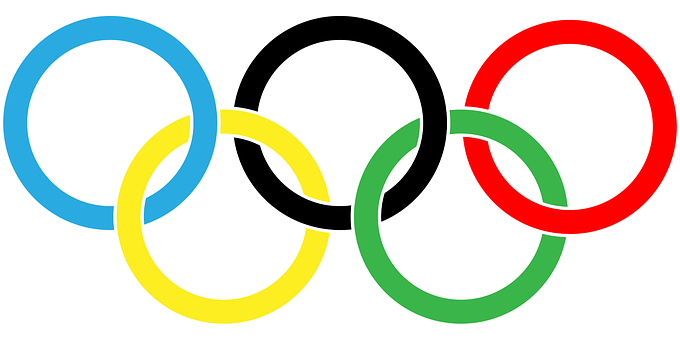

<h1 style="font-family:Georgia; font-size:1.75em;color:black; font-weight:500">
About Olympics </h1>

* The Olympic Games are considered the world's foremost sports competition with more than 200 nations participating.
* The Olympic Games are normally held every four years, and since 1994, have alternated between the Summer and Winter Olympics every two years during the four-year period.



<h2 style="font-family:Georgia; font-size:1.75em;color:black; font-weight:500">
About Input Data </h2>

* 27 lakhs records from 1184 countries from 1904 to 2016
* 16 columns describing the Name, Year, Country, Sports, Medal(won if any), Age, Weight, Height



Reference doc
* What is EDA ? <br>
   https://www.geeksforgeeks.org/exploratory-data-analysis-eda-types-and-tools/
* EDA with an example: <br>
   https://www.geeksforgeeks.org/what-is-exploratory-data-analysis/


* Top 10 countries based on Medal (gold) Tally
* Top 10 countries based on participation
* Participation trend by country,Teams over the years

#### Import the required library

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Read files

In [63]:
df = pd.read_csv('C:\\Rekha\\InputFiles\\Sports_Event_Medal_Dataset.csv')

### Exploring data
df.head() , df.shape , df.info()

In [79]:
df.head(2)

,ID,Name,Gender,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,22,Andreea Aanei,F,22.0,170.0,125.0,Romania,ROU,2016 Summer,2016,Summer,Rio de Janeiro,Weightlifting,Weightlifting Women's Super-Heavyweight,NaN
1,51,Nstor Abad Sanjun,M,23.0,167.0,64.0,Spain,ESP,2016 Summer,2016,Summer,Rio de Janeiro,Gymnastics,Gymnastics Men's Individual All-Around,NaN


In [ ]:
df.info()

In [ ]:
df.size

In [ ]:
df.shape

In [ ]:
df.describe()

#### View data from selected columns on which analysis will be done. 

In [ ]:
#Selecting multiple columns
df[["Age","Year"]].head(2)

In [ ]:
#Selecting multiple columns
df.Age.head(2)

#### Get unique values for categorical data

In [ ]:
df.nunique(axis=0)

In [ ]:
df["Team"].value_counts()


In [ ]:
df["Year"].max()

In [ ]:
df.Sport.value_counts()

In [ ]:
df.Height.value_counts()

In [ ]:
# Identify unique country names
df.Team.unique()  # .size 

In [ ]:
df.Year.unique() 

#### Clean up the data : Rename columns, Replace values in the dataframe,Format date if any
#### Drop columns, Remove duplicates,Address null values


In [66]:
df.rename(columns = {'Gender_1':'Gender','Age_1':'Age'}, inplace = True)
df.head(1)

,ID,Name,Gender,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,22,Andreea Aanei,F,22.0,170.0,125.0,Romania,ROU,2016 Summer,2016,Summer,Rio de Janeiro,Weightlifting,Weightlifting Women's Super-Heavyweight,NaN


In [ ]:
df.replace({"Gender":{'M':'Male','F':'Female'}}).head(2)

#### Adding a new column of date type and formating it

In [ ]:
df["BeginDate"] = pd.to_datetime(df.Year,format="%Y")
df["BeginDate"].dt.strftime("%d-%m-%Y")
df.info()
#pd.to_datetime("1900",format="%Y").strftime("%d-%m-%Y")

In [ ]:
df.drop(columns =['NOC']) # df.drop(columns =['C', 'D']) ==> Multi Column

In [ ]:
df.duplicated().sum()

In [ ]:
# List the duplicates
df[df.duplicated()]

In [ ]:
# Drop the duplicates
df.drop_duplicates()

In [ ]:
#Working with missing values
df.isnull().sum() # of isna

#### * dropping column if it has less than 910 not-null value
#### * or dropping rows with null values

In [ ]:
df.dropna(thresh=270000,axis=1) # axis = 1 columns, we can give threshold to control the drop

In [ ]:
df.dropna(axis=0)

In [77]:
df.Medal.fillna("None")
#df.Medal.fillna(method='backfill')
#df.Medal.fillna(method='ffill')

0           None
1           None
2           None
3           None
4           None
           ...  
271111      None
271112    Silver
271113    Silver
271114      None
271115      Gold
Name: Medal, Length: 271116, dtype: object

In [ ]:
#Creating a test file
# df = pd.read_csv('C:\\Rekha\\InputFiles\\Sports_Event_Medal_Dataset.csv')
# sportsFilter = ['Athletics','Swimming','Gymnastics','Rowing','Fencing','Cycling']
# countries = ['United States','China','Romania','France']

# y = df[df['Team'].isin(countries)]
# y = y[y['Sport'].isin(sportsFilter)]


# y = y[y['Year'] > 2013]
# y.shape

# y.to_csv('C:\\Rekha\\InputFiles\\Sports_Event_Medal_Dataset_temp.csv')
# y.Team.unique()



In [ ]:
#Selection
df[(df.Age>40) & (df.Age<60)]
# To get the count of records.Age.count()

In [ ]:
df[df.Age == df.Age.max()]

#### Perfroming sort on column names and column data 
* Using sort_index() and sort_values()

In [ ]:
df.sort_index(axis=1,ascending=True)

In [ ]:
df.sort_values(by=['Team',"Sport"],ascending=[True,False])
df.head(2)

#### Get Descriptive statistics on Numerical Data

In [ ]:
df[['Age','Height','Weight']].describe()

#### Performing Aggregation operation
#### Get the min, and max values for Age, Height, Weight

In [67]:
df[['Height','Age','Weight']].aggregate(['max','min']) # mean, var, std, sum

,Height,Age,Weight
max,226.0,97.0,214.0
min,127.0,10.0,25.0


In [68]:
df["Year"].unique()

array([2016, 2014, 2012, 2010, 2008, 2006, 2004, 2002, 2000, 1998, 1996,
       1994, 1992, 1988, 1984, 1980, 1976, 1972, 1968, 1964, 1960, 1956,
       1952, 1948, 1936, 1932, 1928, 1924, 1920, 1912, 1908, 1906, 1904,
       1900, 1896], dtype=int64)

#### Sports Participation Table

In [69]:
df["Sport"].value_counts()

Athletics        38624
Gymnastics       26707
Swimming         23195
Shooting         11448
Cycling          10859
                 ...  
Racquets            12
Jeu De Paume        11
Roque                4
Basque Pelota        2
Aeronautics          1
Name: Sport, Length: 66, dtype: int64

### Groupby

In [84]:
collist = ['Sport','Team','ID']
df_chart1 = df[collist].groupby(["Sport","Team"]).count()
df_chart1
df_chart1 = df_chart1.sort_values(by=["Sport","ID"],ascending=False)[:10].reset_index()
df_chart1

,Sport,Team,ID
0,Wrestling,United States,383
1,Wrestling,Sweden,286
2,Wrestling,Hungary,279
3,Wrestling,Finland,274
4,Wrestling,Turkey,266
5,Wrestling,Japan,238
6,Wrestling,Bulgaria,223
7,Wrestling,Great Britain,198
8,Wrestling,France,196
9,Wrestling,Iran,189


<AxesSubplot:xlabel='Team', ylabel='ID'>

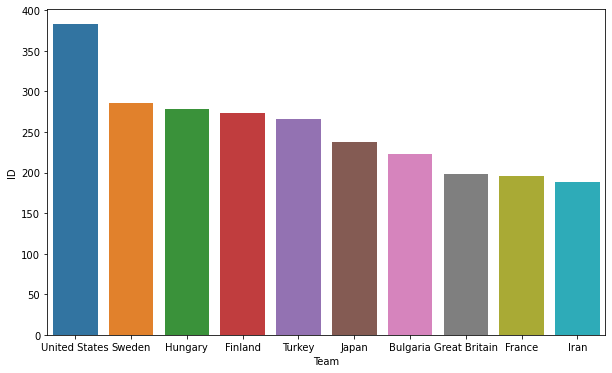

In [85]:
plt.figure(figsize=(10,6))
sns.barplot(x="Team",y="ID",data=df_chart1)

In [86]:
#Gold Medals by country

In [90]:
collist = ['Team','Medal','ID']
df_chart2 = df[collist].groupby(["Team","Medal"]).count()
df_chart2
df_chart2 = df_chart2.reset_index()
df_chart2= df_chart2[df_chart2["Medal"] == "Gold"].sort_values(by="ID",ascending=False)[:6]
df_chart2

,Team,Medal,ID
726,United States,Gold,2474
627,Soviet Union,Gold,1058
263,Germany,Gold,679
351,Italy,Gold,535
277,Great Britain,Gold,519
240,France,Gold,455


### Top 8 countries by Gold Medal

In [94]:
df_gold = df[df["Medal"]=="Gold"].groupby("Team").Medal.count().reset_index()

df_gold = df_gold.sort_values(by="Medal",ascending=False)[:8]
df_gold
 

,Team,Medal
224,United States,2474
200,Soviet Union,1058
87,Germany,679
112,Italy,535
90,Great Britain,519
80,France,455
205,Sweden,451
102,Hungary,432


<AxesSubplot:title={'center':'Top Countires By Gold Medal'}, xlabel='Team', ylabel='Medal'>

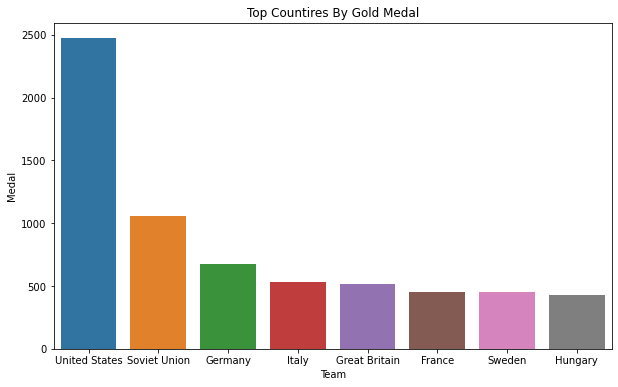

In [95]:
plt.figure(figsize=(10,6))
plt.title("Top Countires By Gold Medal")
sns.barplot(data=df_gold,x="Team",y="Medal")

#### Scatter plot of Medals distribution over year

In [135]:
df["Medal"].fillna("None",inplace=True)
df["Medal_Int"] = df["Medal"]
df["Medal_Int"].replace(["Gold","Silver","Bronze","None"],[1,2,3,4],inplace=True)
df_medals = df.groupby(["Year","Medal"]).count().reset_index()


In [165]:
df_entries = df.groupby(["Year"]).count().reset_index()
moving_avg = df_entries.rolling(window=5).mean()

cum_sum[:5]

,Year,ID,Name,Gender,Age,Height,Weight,Team,NOC,Games,Season,City,Sport,Event,Medal,Medal_Int
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5700.0,3617.0,3617.0,3617.0,2390.0,375.0,275.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0
3,5710.0,4970.0,4970.0,4970.0,3163.0,586.0,431.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0
4,5718.0,6135.0,6135.0,6135.0,4469.0,945.0,835.0,6135.0,6135.0,6135.0,6135.0,6135.0,6135.0,6135.0,6135.0,6135.0


<AxesSubplot:xlabel='Year', ylabel='ID'>

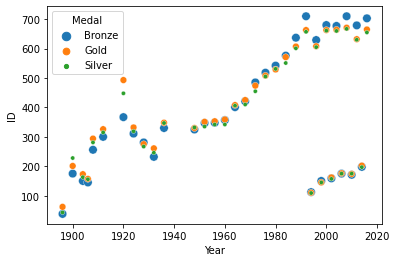

In [139]:
sns.scatterplot(x="Year",y="ID",size="Medal",hue="Medal",data=df_medals[df_medals["Medal"] !="None"])
sns.lineplot(x="Year",y="ID",data=cum_sum)

<AxesSubplot:xlabel='Year', ylabel='ID'>

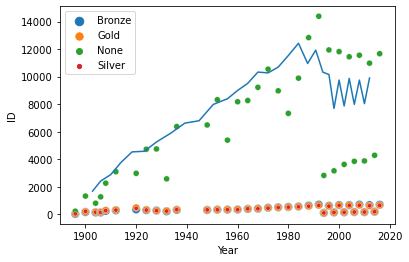

In [167]:
# Scatter plot and Line Plot
sns.scatterplot(x="Year",y="ID",size="Medal",hue="Medal",data=df_medals)
sns.lineplot(x="Year",y="ID",data=moving_avg)



In [174]:
cum_sum["Year"] = df_entries["Year"]
cum_sum["Rolling_Sum"]= df_entries.rolling(window=3).ID.sum()
cum_sum[:4]

,Year,ID,Name,Gender,Age,Height,Weight,Team,NOC,Games,Season,City,Sport,Event,Medal,Medal_Int,Rolling_Sum
0,1896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1904,3617.0,3617.0,3617.0,2390.0,375.0,275.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0,3617.0
3,1906,4970.0,4970.0,4970.0,3163.0,586.0,431.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0,4970.0


<AxesSubplot:xlabel='Year', ylabel='Rolling_Sum'>

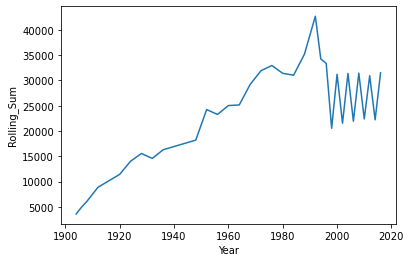

In [175]:
sns.lineplot(x="Year",y="Rolling_Sum",data=cum_sum)


#### Analyze pattern in height od participant

<AxesSubplot:xlabel='Height', ylabel='Team'>

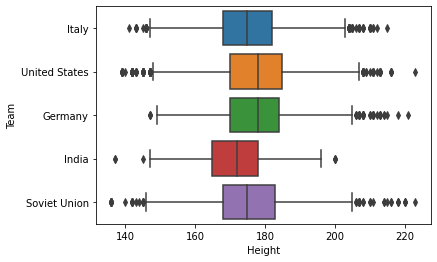

In [91]:
country_list = ["United States","Soviet Union","Germany","Italy","India"]
df_temp = df[df['Team'].isin(country_list)]
sns.boxplot(x='Height',y='Team',data=df_temp)

#### Analyze the pattern in height, weight by gender, by medal

<AxesSubplot:xlabel='Height', ylabel='Weight'>

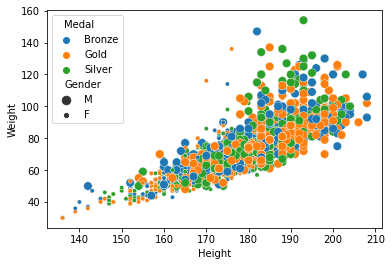

In [93]:
country_list = ["United States","Soviet Union","Germany","Italy","India"]
df_temp = df[df['Team'].isin(country_list)]
sportsFilter = ['Athletics','Swimming','Gymnastics','Rowing','Fencing','Cycling']
df2 = df_temp[df_temp['Sport'].isin(sportsFilter)]

sns.scatterplot( x="Height", y='Weight',hue='Medal',size="Gender", data=df2)

In [ ]:
### Correlation matrix

<AxesSubplot:>

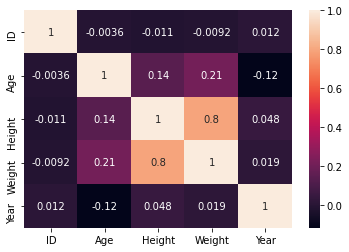

In [97]:
corr = df.corr()# plot the heatmap
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, 
            annot=True)

In [150]:
## Which country has maximum female participation
df_female = df.groupby(["Team","Gender"]).ID.count()
df_female = df_female.reset_index()
df_female.sort_values(by=["Gender","ID"],ascending=[True,False])

,Team,Gender,ID
1418,United States,F,5368
224,Canada,F,3473
531,Great Britain,F,3188
512,Germany,F,2911
467,France,F,2743
...,...,...,...
1456,Uzbekistan-2,M,1
1464,Verveine-19,M,1
1465,Verveine-41,M,1
1496,Whisper,M,1


In [160]:
## Identify repeat winners
df_repeat = df[df["Medal"].isin(["Gold"])]
df_repeat = df_repeat.groupby("Name").count()
df_r = df_repeat.reset_index().sort_values(by="ID",ascending=False)
df_r[df_r["ID"] > 1]

,Name,ID,Gender,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal_Int
6633,"Michael Fred Phelps, II",23,23,23,23,23,23,23,23,23,23,23,23,23,23,23
7836,"Raymond Clarence ""Ray"" Ewry",10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
7386,Paavo Johannes Nurmi,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
5591,Larysa Semenivna Latynina (Diriy-),9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
6336,Mark Andrew Spitz,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3667,Hazel Virginia Wightman (Hotchkiss-),2,2,2,0,0,2,2,2,2,2,2,2,2,2,2
4950,Joy Lynn Fawcett (Biefeld-),2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
1203,Briana Collette Scurry,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
1202,Brian Stuart Goodell,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
